In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image


In [5]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(directory='Medicinal Leaf dataset',shuffle=True,seed=14,batch_size=32,image_size=(224,224))

Found 6900 files belonging to 80 classes.


In [6]:
BATCH_SIZE = 32
IMAGE_SIZE = 224
EPOCHS = 50
CHANNELS = 3
INPUT_SHAPE = (BATCH_SIZE,IMAGE_SIZE,IMAGE_SIZE,CHANNELS)

In [7]:
len(dataset) # Total batches, Each batch contains 32 images

216

In [8]:
class_names = dataset.class_names
n_classes = len(class_names)
print(class_names)
print("Total classes are", n_classes)


['Aloevera', 'Amla', 'Amruthaballi', 'Arali', 'Astma_weed', 'Badipala', 'Balloon_Vine', 'Bamboo', 'Beans', 'Betel', 'Bhrami', 'Bringaraja', 'Caricature', 'Castor', 'Catharanthus', 'Chakte', 'Chilly', 'Citron lime (herelikai)', 'Coffee', 'Common rue(naagdalli)', 'Coriender', 'Curry', 'Doddpathre', 'Drumstick', 'Ekka', 'Eucalyptus', 'Ganigale', 'Ganike', 'Gasagase', 'Ginger', 'Globe Amarnath', 'Guava', 'Henna', 'Hibiscus', 'Honge', 'Insulin', 'Jackfruit', 'Jasmine', 'Kambajala', 'Kasambruga', 'Kohlrabi', 'Lantana', 'Lemon', 'Lemongrass', 'Malabar_Nut', 'Malabar_Spinach', 'Mango', 'Marigold', 'Mint', 'Neem', 'Nelavembu', 'Nerale', 'Nooni', 'Onion', 'Padri', 'Palak(Spinach)', 'Papaya', 'Parijatha', 'Pea', 'Pepper', 'Pomoegranate', 'Pumpkin', 'Raddish', 'Rose', 'Sampige', 'Sapota', 'Seethaashoka', 'Seethapala', 'Spinach1', 'Tamarind', 'Taro', 'Tecoma', 'Thumbe', 'Tomato', 'Tulsi', 'Turmeric', 'ashoka', 'camphor', 'kamakasturi', 'kepala']
Total classes are 80


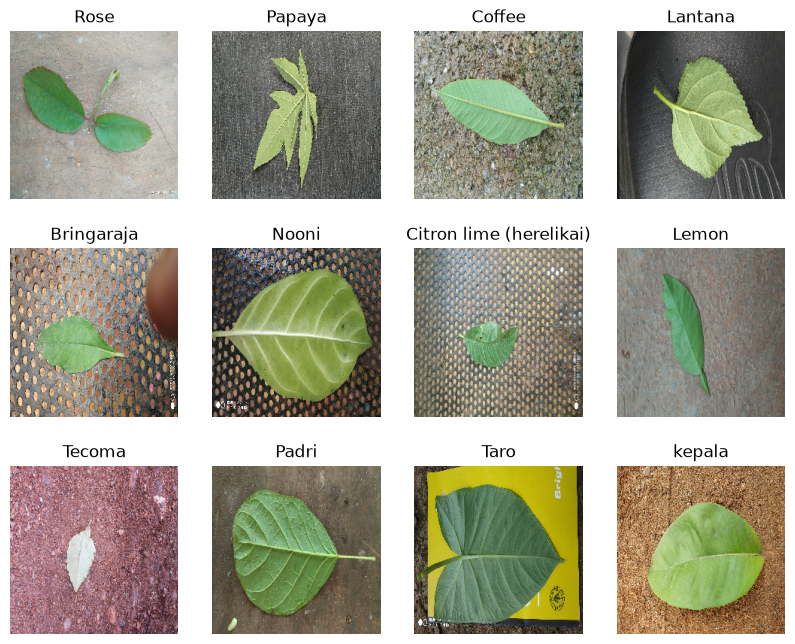

In [9]:
plt.figure(figsize=(10,8))
for image, label in dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3,4,i+1)
        plt.imshow(image[i].numpy().astype('uint8'))
        plt.title(class_names[label[i]])
        plt.axis('off')

In [10]:
def get_preprocessed_image_split(dataset, training_size = 0.8, testing_size = 0.1, validation_size = 0.1, shuffle = True, shuffle_size = 10000):
    ds_len = len(dataset)
    if shuffle:
        dataset = dataset.shuffle(shuffle_size)
    train_len = int(ds_len * training_size)
    train_ds = dataset.take(train_len)
    test_len = int(ds_len * testing_size)
    test_ds = dataset.skip(train_len).take(test_len)
    val_ds = dataset.skip(train_len).skip(test_len)
    
    return train_ds, test_ds, val_ds

In [11]:
train_ds, test_ds, val_ds = get_preprocessed_image_split(dataset)

In [12]:
print("Training Batch:",len(train_ds))
print("Testing Batch:",len(test_ds))
print("Validation Batch:",len(val_ds))
print("Total Batches:",len(dataset))

Training Batch: 172
Testing Batch: 21
Validation Batch: 23
Total Batches: 216


In [13]:
train_ds = train_ds.cache().shuffle(1000).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(tf.data.AUTOTUNE)

In [14]:
resize_and_rescale = keras.Sequential([
    keras.layers.Resizing(IMAGE_SIZE,IMAGE_SIZE),
    keras.layers.Rescaling(1.0/255)
])

In [15]:
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip('horizontal_and_vertical'),
    keras.layers.RandomRotation(0.2),
    keras.layers.RandomZoom(0.2)
])

In [16]:
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y)
).prefetch(tf.data.AUTOTUNE)

In [17]:
base_model = keras.applications.MobileNetV2(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),include_top=False,weights='imagenet')
base_model.trainable = False

In [25]:
model = models.Sequential([
    resize_and_rescale,
    # layers.Input(INPUT_SHAPE),
    base_model,
    # layers.Conv2D(32, kernel_size = (3,3), activation='relu'),
    # layers.MaxPooling2D((2, 2)),
    # layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    # layers.MaxPooling2D((2, 2)),
    # layers.Conv2D(128,  kernel_size = (3,3), activation='relu'),
    # layers.MaxPooling2D((2, 2)),
    # layers.Conv2D(128, (3, 3), activation='relu'),
    # layers.MaxPooling2D((2, 2)),
    # layers.Conv2D(128, (3, 3), activation='relu'),
    # layers.MaxPooling2D((2, 2)),
    # layers.Conv2D(128, (3, 3), activation='relu'),
    # layers.MaxPooling2D((2, 2)),
    layers.GlobalAveragePooling2D(),
    # layers.Flatten(),
    # layers.Dense(128, activation='relu'),
    # layers.Dense(128, activation='relu'),
    # layers.Dense(128, activation='relu'),
    layers.Dense(n_classes, activation='softmax'),
])

In [26]:
model.build(input_shape=INPUT_SHAPE)

In [27]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (32, 224, 224, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (32, 7, 7, 1280)       │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (32, 1280)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 80)               │       102,480 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,360,464 (9.00 MB)

 Trainable params: 102,480 (400.31 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [28]:
model.compile(optimizer='adam',loss=tf.keras.losses.SparseCategoricalCrossentropy(),metrics=['accuracy'])

In [29]:
history = model.fit(train_ds,epochs=EPOCHS,validation_data=val_ds)

Epoch 1/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 142s 646ms/step - accuracy: 0.3592 - loss: 2.7075 - val_accuracy: 0.5842 - val_loss: 1.6589
Epoch 2/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 96s 557ms/step - accuracy: 0.6661 - loss: 1.3587 - val_accuracy: 0.6889 - val_loss: 1.1330
Epoch 3/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 104s 606ms/step - accuracy: 0.7396 - loss: 1.0282 - val_accuracy: 0.7527 - val_loss: 0.8927
Epoch 4/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 111s 646ms/step - accuracy: 0.7895 - loss: 0.8301 - val_accuracy: 0.7826 - val_loss: 0.7748
Epoch 5/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 102s 594ms/step - accuracy: 0.8201 - loss: 0.7114 - val_accuracy: 0.8043 - val_loss: 0.6985
Epoch 6/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 105s 611ms/step - accuracy: 0.8376 - loss: 0.6250 - val_accuracy: 0.8071 - val_loss: 0.6838
Epoch 7/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 106s 615ms/step - accuracy: 0.8602 - loss: 0.5626 - val_accuracy: 0.8329 - val_loss: 0.5983
Epoch 8/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 107s 621ms/step - accuracy: 0.8736 - 

In [31]:
score = model.evaluate(test_ds)
score

21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 272ms/step - accuracy: 0.8765 - loss: 0.4045


[0.4044676721096039, 0.8764880895614624]

In [32]:
history.params
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [33]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

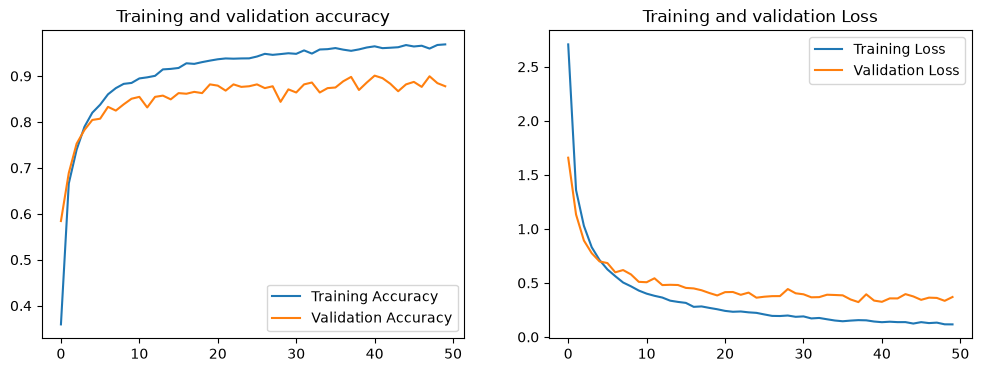

In [34]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(range(EPOCHS),acc,label='Training Accuracy')
plt.plot(range(EPOCHS),val_acc,label='Validation Accuracy')
plt.legend()
plt.title('Training and validation accuracy')

plt.subplot(1,2,2)
plt.plot(range(EPOCHS),loss,label='Training Loss')
plt.plot(range(EPOCHS),val_loss,label='Validation Loss')
plt.legend()
plt.title('Training and validation Loss')
plt.show()

In [35]:
def predict(model, images):
    img_array = tf.keras.preprocessing.image.img_to_array(images.numpy())
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 267ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 858ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


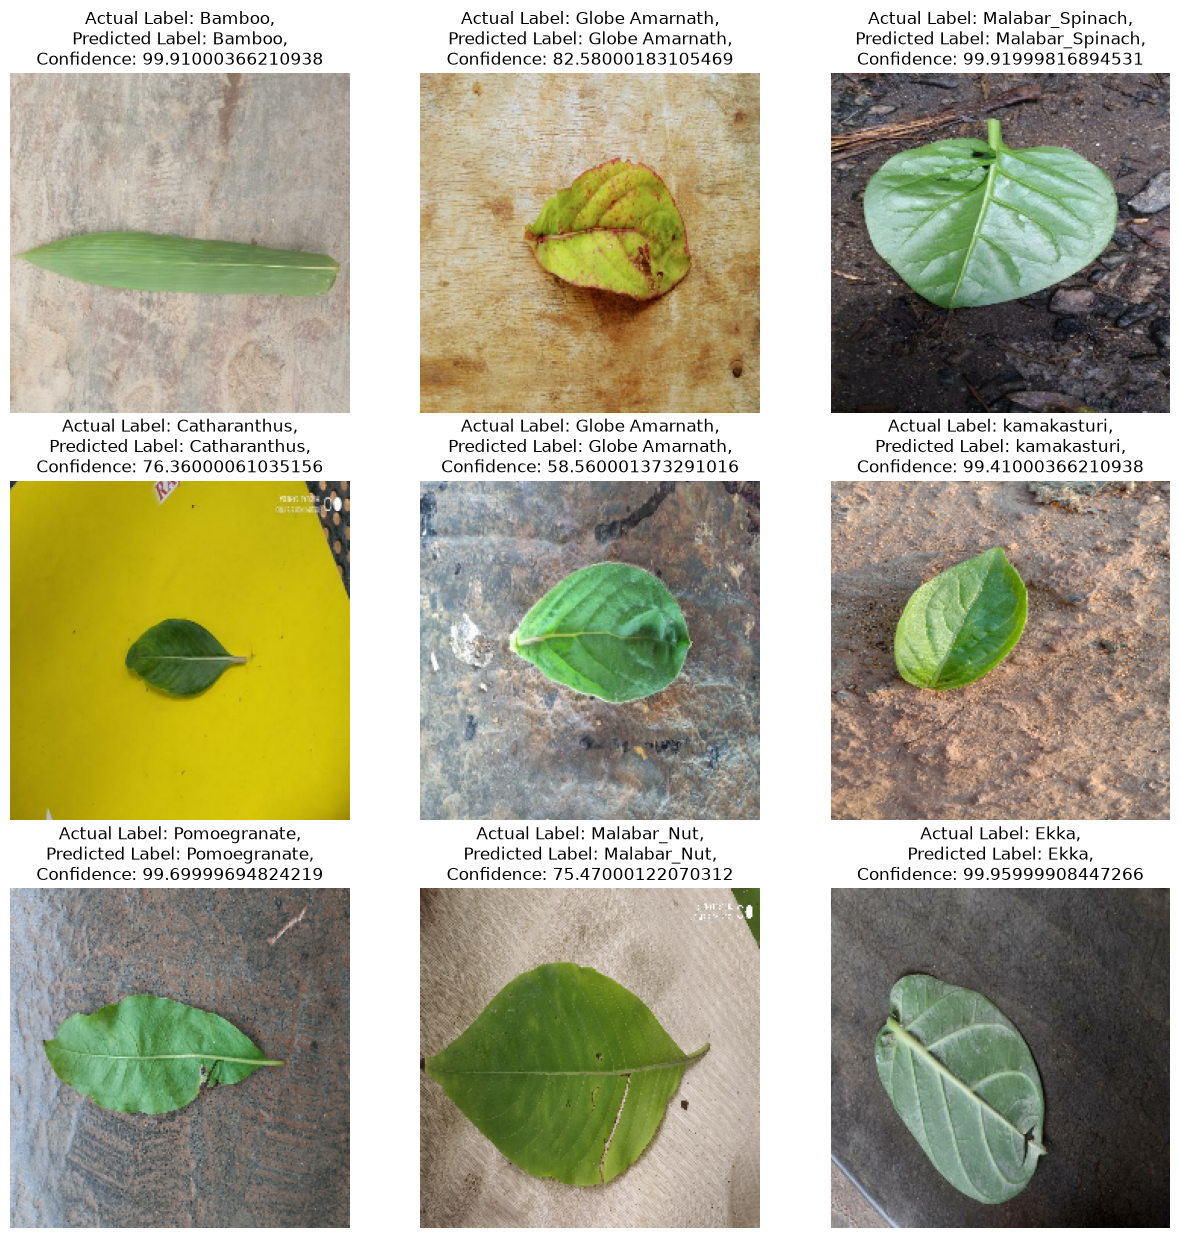

In [36]:
plt.figure(figsize=(15,15))
prediction = model.predict(test_ds)
for image_batch, label in test_ds.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(image_batch[i].numpy().astype('int'))
        actual_label = class_names[label[i].numpy()]
        # predicted_label = class_names[np.argmax(prediction[i])]
        # confidence = round(100 * np.max(prediction[i]),2)
        predicted_label, confidence = predict(model, image_batch[i])
        plt.title(f"Actual Label: {actual_label},\nPredicted Label: {predicted_label},\nConfidence: {confidence}")
        plt.axis('off')

In [ ]:
# import os
# model_version = max([int(i) for i in os.listdir('saved_models')])+1
# model.save(f'saved_models/{model_version}.keras')

ValueError: invalid literal for int() with base 10: '1.keras'

In [53]:
model.save(f'saved_models/model_1.keras')